# PCOS Diagnosis — Random Forest Pipeline
**Dataset:** 541 Indian women (177 PCOS, 364 controls) | **Target:** `pcos_y_n`

This notebook covers:
1. Data loading & preprocessing (same pipeline as XGBoost notebook)
2. Hyperparameter tuning via `RandomizedSearchCV`
3. 5-fold stratified CV evaluation on **full** and **low-cost non-invasive** feature sets
4. Feature importance plot
5. Export of fold-level AUC scores for use in `07-model-comparison.ipynb`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_validate, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

print('Imports successful')

Imports successful


## 1. Load & Preprocess Data

In [2]:
data_path = '../data/processed/cleaned_data.csv'
df = pd.read_csv(data_path)

# Drop ID columns
df = df.drop(columns=['sl_no', 'patient_file_no'], errors='ignore')

# Coerce string column to numeric (known issue from cleaning notebook)
df['ii_beta_hcg_miu_ml'] = pd.to_numeric(df['ii_beta_hcg_miu_ml'], errors='coerce')

# Fill missing values with column median
df = df.fillna(df.median(numeric_only=True))

print(f'Shape: {df.shape}')
print(f'PCOS prevalence: {df["pcos_y_n"].mean():.1%}')
df.head()

Shape: (541, 42)
PCOS prevalence: 32.7%


,pcos_y_n,age_yrs,weight_kg,heightcm,bmi,blood_group,pulse_ratebpm,rr_breaths_min,hbg_dl,cycle_r_i,...,pimples_y_n,fast_food_y_n,reg_exercise_y_n,bp_systolic_mmhg,bp_diastolic_mmhg,follicle_no_l,follicle_no_r,avg_f_size_l_mm,avg_f_size_r_mm,endometrium_mm
0,0,28.0,44.6,152.0,19.304017,15.0,78.0,22.0,10.48,0,...,0,1,0,110.0,80.0,3.0,3.0,18.0,18.0,8.5
1,0,36.0,65.0,161.5,24.921163,15.0,74.0,20.0,11.70,0,...,0,0,0,120.0,70.0,3.0,5.0,15.0,14.0,3.7
2,1,33.0,68.8,165.0,25.270891,11.0,72.0,18.0,11.80,0,...,1,1,0,120.0,80.0,13.0,15.0,18.0,20.0,10.0
3,0,37.0,65.0,148.0,29.674945,13.0,72.0,20.0,12.00,0,...,0,0,0,120.0,70.0,2.0,2.0,15.0,14.0,7.5
4,0,25.0,52.0,161.0,20.060954,11.0,72.0,18.0,10.00,0,...,0,0,0,120.0,80.0,3.0,4.0,16.0,14.0,7.0


## 2. Define Feature Sets

Two feature sets, consistent with the report and dashboard:
- **Full**: all clinical features (includes ultrasound + blood panel)
- **Low-cost non-invasive**: excludes ultrasound measurements and specialised hormonal biomarkers

In [3]:
# Full feature set — all features except the target
full_features = [c for c in df.columns if c != 'pcos_y_n']

# Low-cost non-invasive — mirrors the dashboard Non-Invasive Model
# Excludes: follicle counts, ovarian volumes, endometrium, FSH, LH, AMH, TSH, PRL,
#           Vitamin D3, PRG, RBS, avg follicle sizes, HCG
low_cost_features = [
    'age_yrs', 'bmi', 'weight_kg', 'waist_hip_ratio',
    'pulse_ratebpm', 'rr_breaths_min', 'cycle_r_i', 'cycle_lengthdays',
    'bp_systolic_mmhg', 'bp_diastolic_mmhg',
    'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n',
    'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n',
    'reg_exercise_y_n', 'pregnant_y_n'
]

X_full = df[full_features]
X_low  = df[low_cost_features]
y      = df['pcos_y_n']

print(f'Full feature set:     {len(full_features)} features')
print(f'Low-cost feature set: {len(low_cost_features)} features')

Full feature set:     41 features
Low-cost feature set: 18 features


## 3. Hyperparameter Tuning (Full Feature Set)

`RandomizedSearchCV` with 3-fold inner CV, optimising for ROC-AUC.
StandardScaler is applied inside the pipeline to prevent data leakage.

In [4]:
from sklearn.model_selection import train_test_split

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train_full.shape[0]}  |  Test: {X_test_full.shape[0]}')

Train: 432  |  Test: 109


In [12]:
param_dist = {
    'rf__n_estimators':      [100, 200, 300, 500],
    'rf__max_depth':         [None, 5, 10, 15, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf':  [1, 2, 4],
    'rf__max_features':      ['sqrt', 'log2', 0.5],
    'rf__class_weight':      ['balanced', None],
}

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_full = RandomizedSearchCV(
    pipe_full, param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_full.fit(X_train_full, y_train)

print(f'Best CV AUC (full): {search_full.best_score_:.4f}')
print(f'Best params: {search_full.best_params_}')

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best CV AUC (full): 0.9586
Best params: {'rf__n_estimators': 500, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': 20, 'rf__class_weight': None}


## 4. Outer 5-Fold CV Evaluation — Full Feature Set

In [13]:
best_params_full = {k.replace('rf__', ''): v for k, v in search_full.best_params_.items()}

best_rf_full = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(**best_params_full, random_state=42, n_jobs=-1))
])

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'precision': 'precision',
    'recall':    'recall',
    'f1':        'f1',
    'roc_auc':   'roc_auc',
}

cv_results_full = cross_validate(
    best_rf_full, X_full, y,
    cv=outer_cv,
    scoring=scoring,
    return_train_score=False
)

print('Random Forest — Full Feature Set (5-fold CV):')
print('=' * 50)
for metric, scores in cv_results_full.items():
    if metric.startswith('test_'):
        name = metric.replace('test_', '')
        print(f'  {name:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# Store fold-level AUC for model comparison notebook
fold_auc_full = cv_results_full['test_roc_auc']
print(f'\nFold-level AUC (full): {fold_auc_full}')

Random Forest — Full Feature Set (5-fold CV):
  accuracy    : 0.9020 ± 0.0297
  precision   : 0.9182 ± 0.0346
  recall      : 0.7686 ± 0.0712
  f1          : 0.8356 ± 0.0532
  roc_auc     : 0.9613 ± 0.0101

Fold-level AUC (full): [0.95053272 0.94990215 0.96360078 0.97690802 0.96566358]


## 5. Hyperparameter Tuning & CV Evaluation — Low-Cost Feature Set

In [14]:
X_train_low, X_test_low, _, _ = train_test_split(
    X_low, y, test_size=0.2, stratify=y, random_state=42
)

pipe_low = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

search_low = RandomizedSearchCV(
    pipe_low, param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_low.fit(X_train_low, y_train)

print(f'Best CV AUC (low-cost): {search_low.best_score_:.4f}')
print(f'Best params: {search_low.best_params_}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best CV AUC (low-cost): 0.8875
Best params: {'rf__n_estimators': 200, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 'log2', 'rf__max_depth': 20, 'rf__class_weight': 'balanced'}


In [8]:
best_params_low = {k.replace('rf__', ''): v for k, v in search_low.best_params_.items()}

best_rf_low = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(**best_params_low, random_state=42, n_jobs=-1))
])

cv_results_low = cross_validate(
    best_rf_low, X_low, y,
    cv=outer_cv,
    scoring=scoring,
    return_train_score=False
)

print('Random Forest — Low-Cost Feature Set (5-fold CV):')
print('=' * 50)
for metric, scores in cv_results_low.items():
    if metric.startswith('test_'):
        name = metric.replace('test_', '')
        print(f'  {name:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

fold_auc_low = cv_results_low['test_roc_auc']
print(f'\nFold-level AUC (low-cost): {fold_auc_low}')

Random Forest — Low-Cost Feature Set (5-fold CV):
  accuracy    : 0.8318 ± 0.0301
  precision   : 0.7508 ± 0.0473
  recall      : 0.7294 ± 0.0555
  f1          : 0.7392 ± 0.0465
  roc_auc     : 0.8870 ± 0.0235

Fold-level AUC (low-cost): [0.88812785 0.88571429 0.92563601 0.85166341 0.88387346]


## 6. Summary Table (matches report Table 2 format)

In [9]:
auc_full = cv_results_full['test_roc_auc']
auc_low  = cv_results_low['test_roc_auc']

summary = pd.DataFrame({
    'Model':                  ['Random Forest'],
    'Full Feature Set AUC':   [f"{auc_full.mean():.4f} (±{auc_full.std():.3f})"],
    'Low-Cost Feature Set AUC': [f"{auc_low.mean():.4f} (±{auc_low.std():.3f})"],
    'AUC Gap':                [f"{(auc_full.mean() - auc_low.mean()):.4f}"]
})

print('Table to add to report Table 2:')
print(summary.to_string(index=False))

Table to add to report Table 2:
        Model Full Feature Set AUC Low-Cost Feature Set AUC AUC Gap
Random Forest      0.9613 (±0.010)          0.8870 (±0.023)  0.0743


## 7. Feature Importance Plot (Full Model)

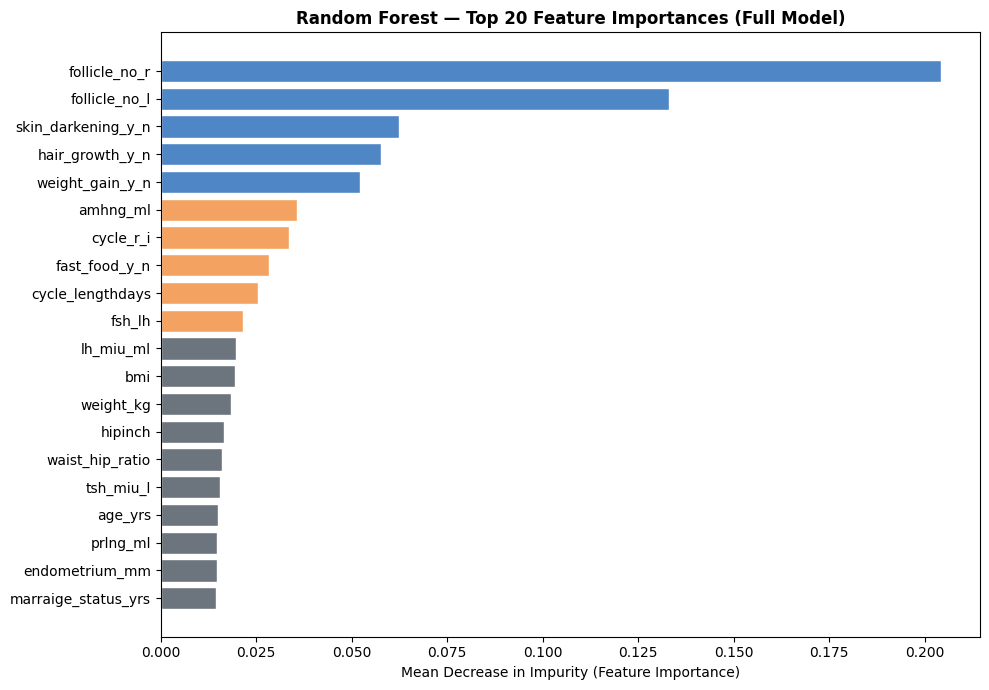

Saved to data/processed/rf_feature_importance.png


In [10]:
# Fit final model on all data for feature importance
best_rf_full.fit(X_full, y)
rf_model = best_rf_full.named_steps['rf']

importance_df = pd.DataFrame({
    'Feature':    full_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#4F86C6' if i < 5 else '#F4A261' if i < 10 else '#6c757d'
          for i in range(len(importance_df))]
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Random Forest — Top 20 Feature Importances (Full Model)', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/rf_feature_importance.png')

## 8. Export Fold-Level AUC Scores

Saved to `data/processed/rf_fold_auc.csv` for use in `07-model-comparison.ipynb`.

In [11]:
fold_df = pd.DataFrame({
    'fold':          range(1, 6),
    'rf_full_auc':   cv_results_full['test_roc_auc'],
    'rf_low_auc':    cv_results_low['test_roc_auc'],
})

fold_df.to_csv('../data/processed/rf_fold_auc.csv', index=False)
print('Saved fold-level AUC scores:')
print(fold_df.to_string(index=False))

Saved fold-level AUC scores:
 fold  rf_full_auc  rf_low_auc
    1     0.950533    0.888128
    2     0.949902    0.885714
    3     0.963601    0.925636
    4     0.976908    0.851663
    5     0.965664    0.883873
